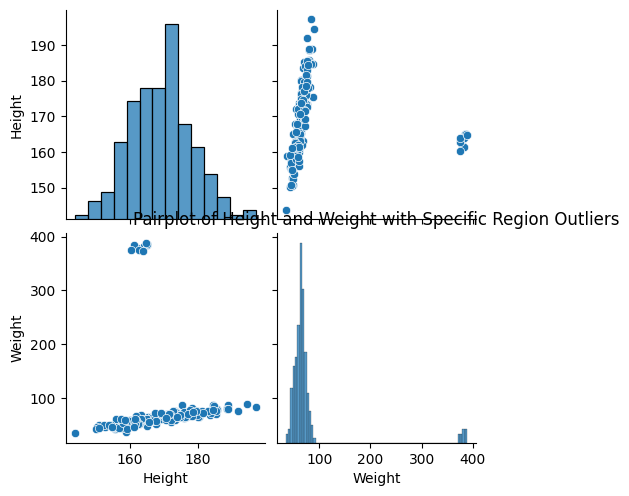

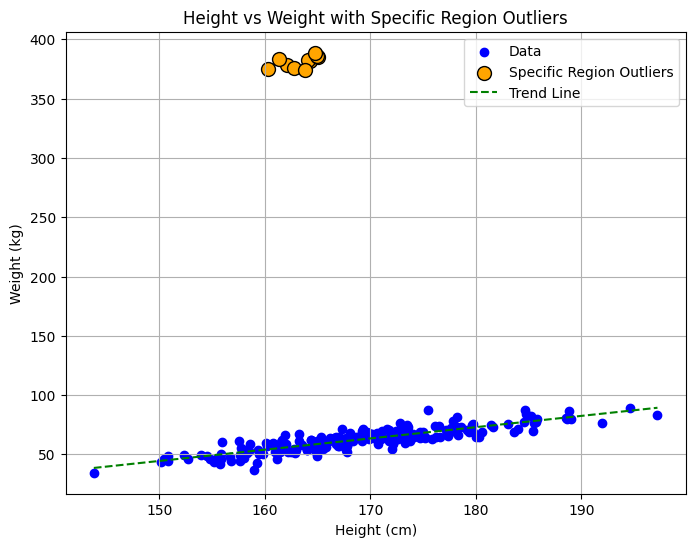

Specific Region Outliers:
         Height      Weight
15   164.377125   61.734258
18   160.919759   52.400966
24   164.556173   55.740896
28   163.993613   54.017733
30   163.982934   53.932807
45   162.801558   54.848896
52   163.230780   67.518483
56   161.607825   61.781598
69   163.548802   57.847625
83   164.817298   52.146491
84   161.915064   66.388724
85   164.982430   48.723748
88   164.702398   59.637118
92   162.979469   53.734698
103  161.977227   58.831356
121  160.906125   57.791298
126  160.094637   59.875727
127  164.337023   61.861634
129  164.965243   61.610447
134  160.805758   59.600781
136  162.167467   51.823234
152  163.199753   61.168076
155  162.856486   51.558190
160  160.253183   56.824598
163  161.793177   57.622418
169  162.462638   52.351326
170  161.104856   55.116921
171  161.841897   58.147699
181  161.428424   52.288619
188  161.532063   60.130976
196  161.161426   46.479610
200  162.074098  378.786721
201  161.367035  383.797767
202  160.281877  374.8

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 키와 몸무게의 양의 상관관계에서 특정 영역에서의 이상치 예시
np.random.seed(42)

# 정상 데이터 생성 (키와 몸무게 관계)
height = np.random.normal(170, 10, 200)  # 평균 170cm, 표준편차 10cm
weight = (height - 100) * 0.9 + np.random.normal(0, 5, size=height.shape)  # 일반적인 키-몸무게 관계

# 특정 영역에서의 이상치 추가
specific_height = np.random.uniform(160, 165, 10)  # 특정 키 범위
specific_weight = specific_height * 0.5 + 300 + np.random.normal(0, 5, size=specific_height.shape)  # 특정 영역의 이상치

# 기존 데이터와 결합
height_with_specific = np.concatenate([height, specific_height])
weight_with_specific = np.concatenate([weight, specific_weight])

# 데이터프레임 생성
specific_data = pd.DataFrame({"Height": height_with_specific, "Weight": weight_with_specific})

# Pairplot 시각화
sns.pairplot(specific_data, kind="scatter")
plt.title("Pairplot of Height and Weight with Specific Region Outliers")
plt.show()

# 산점도에서 특정 영역 이상치 강조
plt.figure(figsize=(8, 6))
plt.scatter(specific_data['Height'], specific_data['Weight'], label="Data", color="blue")
plt.scatter(specific_height, specific_weight, label="Specific Region Outliers", color="orange", edgecolor="black", s=100)

# 정상 데이터 경향선 추가
slope, intercept = np.polyfit(height, weight, 1)  # 정상 데이터 기준 경향선
x_range = np.linspace(min(height_with_specific), max(height_with_specific), 100)
plt.plot(x_range, slope * x_range + intercept, color="green", linestyle="--", label="Trend Line")

plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height vs Weight with Specific Region Outliers")
plt.legend()
plt.grid(True)
plt.show()

# 특정 영역에서의 이상치 데이터 분리
specific_region_mask = (specific_data['Height'] >= 160) & (specific_data['Height'] <= 165)
specific_region_outliers = specific_data[specific_region_mask]
normal_data = specific_data[~specific_region_mask]

# 분리된 데이터 출력
print("Specific Region Outliers:")
print(specific_region_outliers)
print("\nNormal Data:")
print(normal_data)

# 그래프 특징 설명:
# 이 그래프는 키와 몸무게의 양의 상관관계를 보여줍니다. 
# 정상 데이터는 일정한 상관계수를 가지며 일정한 기울기의 경향선을 따릅니다.
# 그러나 특정 키 범위(160~165cm)에서는 오렌지색 점으로 표시된 이상치가 나타납니다. 
# 이 이상치들은 기존 경향선과는 다른 기울기를 가지며, 특정 영역에서의 돌발적 변화를 시사합니다.
# 특정 영역의 이상치는 별도로 분리하여 분석하거나, 데이터 정제 과정에서 처리할 수 있습니다.
